In [73]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sbn

In [138]:
Ideal_condition = pd.read_csv("Ideal_1.csv")
Ideal_condition_1 = pd.read_csv("Ideal_2.csv")
Good_run1 = pd.read_csv("Good_run_1.csv")
Good_run2 = pd.read_csv("Good_run_2.csv")
Fallen_run1 = pd.read_csv("Fallen_run_1.csv")
Fallen_run2 = pd.read_csv("Fallen_run_2.csv")
Minor_imbalance = pd.read_csv("Minor_imbalance.csv")
Major_imbalance = pd.read_csv("Major_imbalance.csv")
Minor_imbalance_1 = pd.read_csv("Minor_imbalance_1.csv")
Major_imbalance_1 = pd.read_csv("Major_imbalance_1.csv")
Minor_imbalance_2 = pd.read_csv("Minor_imbalance_2.csv")
Major_imbalance_2 = pd.read_csv("Major_imbalance_2.csv")
Heavy_obstacle = pd.read_csv("Heavy_obstacle.csv")
Minor_obstacle = pd.read_csv("Minor_obstacle.csv")

In [139]:
Minor_imbalance = Minor_imbalance.rename(columns={'current_mA': 'current_A'}, inplace=True)

In [140]:
Minor_imbalance = pd.concat([Minor_imbalance, Minor_imbalance_1, Minor_imbalance_2], ignore_index=True)
Major_imbalance = pd.concat([Major_imbalance, Major_imbalance_1, Major_imbalance_2], ignore_index=True)

In [141]:

Ideal_condition = Ideal_condition.drop(columns=["time", "Unnamed: 6"])
Ideal_condition_1 = Ideal_condition_1.drop(columns=["time", "Unnamed: 6"])
Good_run1 = Good_run1.drop(columns=["time", "Unnamed: 6"])
Good_run2 = Good_run2.drop(columns=["time", "Unnamed: 6"])
Fallen_run1 = Fallen_run1.drop(columns=["time", "Unnamed: 6"])
Fallen_run2 = Fallen_run2.drop(columns=["time", "Unnamed: 6"])
Minor_imbalance = Minor_imbalance.drop(columns=["time", "Unnamed: 6"])
Major_imbalance = Major_imbalance.drop(columns=["time", "Unnamed: 6"])
Heavy_obstacle = Heavy_obstacle.drop(columns=["time", "Unnamed: 6"])
Minor_obstacle = Minor_obstacle.drop(columns=["time", "Unnamed: 6"])

In [142]:
Ideal_condition["Output"] = 0
Ideal_condition_1["Output"] = 0
Good_run1["Output"] = 1
Good_run2["Output"] = 1
Fallen_run1["Output"] = 2
Fallen_run2["Output"] = 2
Minor_imbalance["Output"] = 3
Major_imbalance["Output"] = 4
Heavy_obstacle["Output"] = 5
Minor_obstacle["Output"] = 6

In [151]:
Ultimate_Data = pd.concat([Ideal_condition, Ideal_condition_1, Good_run1, Good_run2, Fallen_run1, Fallen_run2, Heavy_obstacle, Minor_obstacle], ignore_index= True)

In [153]:
Ultimate_Data.rename(columns={'current_mA': 'current_A'}, inplace=True)

In [154]:
Ultimate_Data = pd.concat([Ultimate_Data, Minor_imbalance, Major_imbalance], ignore_index=True)

In [156]:
Ultimate_Data = shuffle(Ultimate_Data).reset_index(drop=True)

In [157]:
Ultimate_Data

,accel_g_x,accel_g_y,accel_g_z,bus_voltage_V,current_A,Output
0,-0.017578,-0.064209,1.018555,0.736,1.137,1
1,0.048584,-0.114502,0.910889,1.152,1.592,6
2,0.060791,-0.028320,0.958008,0.780,-0.002,0
3,1.023438,-0.005371,-0.053467,0.772,-0.002,0
4,0.071289,0.538574,1.569824,1.244,1.146,4
...,...,...,...,...,...,...
562821,0.140137,-0.527832,0.826416,0.740,1.138,4
562822,0.059570,-0.024658,0.953857,0.768,-0.008,0
562823,0.012207,-0.409668,1.170898,0.000,1.857,4
562824,1.005371,0.026855,-0.055420,0.916,1.361,2


In [158]:
x = Ultimate_Data[['accel_g_x', 'accel_g_y', 'accel_g_z', 'bus_voltage_V', 'current_A']].values
y = Ultimate_Data['Output'].values

In [159]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [160]:
model = tf.keras.Sequential([
    keras.layers.Input(shape=(5,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(7, activation='softmax')
])


model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)


model.fit (x_train, y_train, epochs=50)

Epoch 1/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 45s 3ms/step - accuracy: 0.8704 - loss: 0.3469
Epoch 2/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9327 - loss: 0.1799
Epoch 3/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9475 - loss: 0.1460
Epoch 4/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9529 - loss: 0.1322
Epoch 5/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 499s 41ms/step - accuracy: 0.9570 - loss: 0.1239
Epoch 6/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - accuracy: 0.9590 - loss: 0.1186
Epoch 7/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9613 - loss: 0.1142
Epoch 8/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9622 - loss: 0.1101
Epoch 9/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9637 - loss: 0.1068
Epoch 10/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9647 - loss: 0.1042
Epoch 11/50
12312/12312 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9657 - loss: 0.

In [161]:
predicted = model(x_test)
predicted = predicted.numpy()
predicted_class = predicted.argmax(axis=1)

In [162]:
predicted_class

array([1, 5, 0, ..., 2, 2, 4], shape=(168848,))

In [163]:
y_test

array([1, 5, 0, ..., 2, 2, 4], shape=(168848,))

<Axes: >

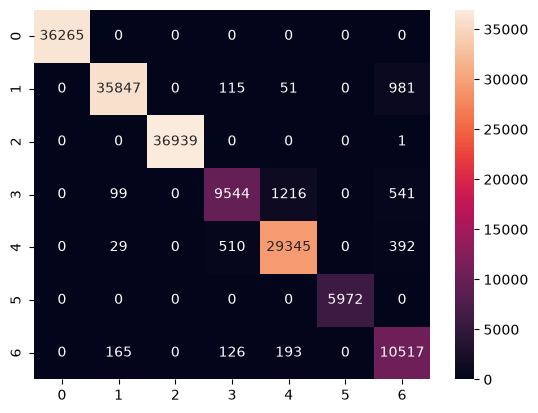

In [164]:
cm=tf.math.confusion_matrix(predicted_class, y_test)
sbn.heatmap(cm, annot=True, fmt='d')

In [165]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
lite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmp1s06evld\assets


INFO:tensorflow:Assets written to: C:\Users\rajmo\AppData\Local\Temp\tmp1s06evld\assets


Saved artifact at 'C:\Users\rajmo\AppData\Local\Temp\tmp1s06evld'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor_14')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2241095250000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241095249424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241095247312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241095249616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241095248848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241095251344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241095252496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2241095252112: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [166]:
with open('Lite_model.tflite', 'wb') as f:
    f.write(lite_model)

In [167]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 16)                  │              96 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,863 (15.09 KB)

 Trainable params: 1,287 (5.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,576 (10.07 KB)

In [40]:
Ideal_condition__ = Ideal_condition.drop(columns=["Output"])

In [168]:
test = pd.read_csv("test.csv")
test = test.drop(columns=["time", "Unnamed: 6"])

In [169]:
test

,accel_g_x,accel_g_y,accel_g_z,bus_voltage_V,current_A
0,0.005615,-0.572754,0.855469,0.848,1.720
1,0.032227,-0.650879,0.674561,0.792,1.165
2,0.032227,-0.650879,0.674561,0.792,1.165
3,0.110596,-0.418213,0.901855,0.792,1.165
4,0.110596,-0.418213,0.901855,0.884,1.643
...,...,...,...,...,...
8285,0.012695,0.592529,0.772217,0.720,2.046
8286,0.012695,0.592529,0.772217,0.720,1.121
8287,0.012695,0.592529,0.772217,0.720,1.121
8288,0.012695,0.592529,0.772217,0.720,1.121


In [170]:

predicted = model(test)
predicted = predicted.numpy()
predicted_class = predicted.argmax(axis=1)

In [171]:
np.unique(predicted_class, return_counts=True)

(array([1, 3, 4, 6]), array([   6, 6103, 1808,  373]))